# 📚 Study Hours Dataset: Linear Regression দিয়ে Exam Score Prediction (Class 3.1)

## 📌 ভূমিকা (Introduction)

এই নোটবুকে আমরা একটি **Simple Linear Regression** মডেল তৈরি করব, যা একজন শিক্ষার্থীর **Study Hours (পড়াশোনার সময়)** এর উপর ভিত্তি করে তার **Exam Score (পরীক্ষার নাম্বার)** প্রেডিক্ট করবে।

### আমাদের লক্ষ্য (Our Task):
- Dataset লোড করে দেখা
- দুটি Variable এর মধ্যে **Correlation (সম্পর্ক)** বিশ্লেষণ করা — Heatmap দিয়ে visualize করা
- Independent (X) ও Dependent (Y) Variable চিহ্নিত করা
- Dataset কে **Training** ও **Testing** অংশে ভাগ করা
- **Linear Regression** মডেল ট্রেইন করা
- Test Data দিয়ে Prediction করে Actual Result এর সাথে তুলনা করা

### 🧠 Linear Regression কী এবং কেন?

Linear Regression হলো একটি **Supervised Machine Learning Algorithm**, যা দুটি ভ্যারিয়েবলের মধ্যে একটি **Linear (সরলরৈখিক) সম্পর্ক** খুঁজে বের করে এবং একটি সরলরেখা (Best Fit Line) তৈরি করে।

$$y = mx + c$$

যেখানে:
- $y$ = Predicted value (Exam Score)
- $x$ = Input feature (Study Hours)
- $m$ = Slope (Coefficient) — x বাড়লে y কতটা বাড়ে/কমে
- $c$ = Intercept — যখন x=0 তখন y এর মান

### কেন এই অ্যালগরিদম?
আমাদের Dataset-এ "Hours of Study" এবং "Exam Score" দুটোই **Continuous Numerical Value** (অর্থাৎ যেকোনো decimal value হতে পারে, যেমন 5.5 ঘণ্টা বা 78.3 স্কোর)। যখন Target Variable (Output) Continuous হয়, তখন **Regression** Algorithm ব্যবহার করা হয় (Classification নয়)।

---

## 🐼 কেন Pandas?

**Pandas** একটি Python Library যা মূলত **Dataset Read/Write এবং ম্যানিপুলেশনের** জন্য ব্যবহার হয়। CSV, Excel, JSON ইত্যাদি ফরম্যাটের ডেটা সহজেই DataFrame এ রূপান্তর করা যায়।

**Pandas er kaj Dataset ke read/write korte sahajjo kore** ✅

| Library | কাজ |
|---|---|
| `pandas` (pd) | ডেটা লোড, পরিষ্কার ও ম্যানিপুলেট করার জন্য |
| `matplotlib.pyplot` (plt) | ডেটা ভিজুয়ালাইজেশন/প্লটিং এর জন্য |

> 💡 **নোট:** `import pandas as pd` লেখার কারণ হলো — পুরো কোডে বারবার `pandas` লেখার বদলে ছোট করে `pd` লেখা সুবিধাজনক। এটি একটি Python কনভেনশন (সবাই এই শর্টফর্ম ব্যবহার করে)।

In [40]:
#import pandas e enough but pandas ke choto korar jonne pd likhchi
import pandas as pd
import matplotlib.pyplot as plt

## 📂 ডেটাসেট লোড ও প্রাথমিক পর্যবেক্ষণ

`pd.read_csv()` দিয়ে CSV ফাইল থেকে ডেটা লোড করে একটি DataFrame তৈরি হচ্ছে, এবং `head(10)` দিয়ে প্রথম ১০টি row দেখা হচ্ছে।

### কেন `head()` দিয়ে দেখা জরুরি?
- কলামগুলোর নাম ও ডেটা টাইপ বোঝা যায়
- ডেটার ভেতরে কোনো অস্বাভাবিক ভ্যালু আছে কিনা প্রাথমিক ধারণা পাওয়া যায়
- Total dataset না দেখে কেবল sample দেখলে memory ও সময় কম লাগে

> ⚠️ **সাধারণ ভুল:** Colab-এ ফাইল পাথ ভুল দিলে (`/content/...` ছাড়া বা ফাইল আপলোড না করে রান করলে) `FileNotFoundError` আসবে। Colab-এ ফাইল প্রথমে বাম পাশের **Files** সেকশনে আপলোড করে নিতে হয়।

In [41]:
dataset= pd.read_csv('/content/Study_Hours.csv')
dataset.head(10)
# dataset =pd.read_csv("Study_Hours.csv")
# pd.read dara bujhay pandas diye read korbo
# jehetu csv file tai csv likhechi read er por

,Hours of Study,Exam Score
0,1.2,300
1,1.7,470
2,4.0,500
3,6.0,600
4,5.5,500
5,6.3,700
6,6.6,850
7,3.2,480
8,6.5,810
9,4.5,490


# 📈 Correlation Analysis (সম্পর্ক বিশ্লেষণ)

## 🧠 থিওরি: কেন Linear Regression?

**Linear Regresssion Aply korbo karon Data hocche continuous data** — যেহেতু "Hours of Study" এবং "Exam Score" দুটোই Continuous Numerical Data, তাই Linear Regression Apply করা যুক্তিযুক্ত।

## 🔗 Correlation (`corr()`) কী?

**Correlation** হলো দুটি Variable এর মধ্যে **সম্পর্কের শক্তি ও দিক (direction)** পরিমাপ করার একটি Statistical পদ্ধতি। এর মান **-1 থেকে +1** এর মধ্যে থাকে।

$$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}$$

| Correlation মান | অর্থ |
|---|---|
| **+1** | Perfect Positive Correlation (একটা বাড়লে অন্যটাও বাড়ে) |
| **0** | কোনো সম্পর্ক নেই |
| **-1** | Perfect Negative Correlation (একটা বাড়লে অন্যটা কমে) |

### কেন Correlation দেখা জরুরি?
- Machine Learning Model বানানোর আগে বুঝতে হয় কোন Feature, Target Variable এর উপর কতটা প্রভাব ফেলে
- যদি Correlation প্রায় **0** হয়, তাহলে সেই Feature দিয়ে Linear Regression করার মানে নেই
- আমাদের ক্ষেত্রে "Hours of Study" বাড়লে "Exam Score" বাড়বে — এটাই আমরা Correlation দিয়ে যাচাই করব

> ⚠️ **সাধারণ ভুল:** Correlation বেশি (যেমন 0.9) মানেই Causation (কারণ-ফলাফল সম্পর্ক) প্রমাণিত হয় না। এটি শুধু সম্পর্কের শক্তি দেখায়।

In [42]:
dataset.corr()

,Hours of Study,Exam Score
Hours of Study,1.000000,0.839407
Exam Score,0.839407,1.000000


## 🌡️ Heatmap দিয়ে Correlation Visualize করা

**Seaborn (sns)** একটি Visualization Library, যা Matplotlib এর উপর ভিত্তি করে তৈরি এবং আরও সুন্দর, Statistical গ্রাফ তৈরি করতে সাহায্য করে।

`sns.heatmap()` ফাংশন Correlation Matrix কে রঙিন গ্রিড (Heatmap) আকারে দেখায় — যেখানে রঙের তীব্রতা সম্পর্কের মাত্রা বোঝায়।

> 💡 **টিপস:** শুধু রঙ দেখে সম্পর্কের সঠিক মান বোঝা কঠিন, এজন্য পরের ধাপে `annot=True` ব্যবহার করা হবে যাতে প্রতিটি সেলে আসল সংখ্যা দেখা যায়।

<Axes: >

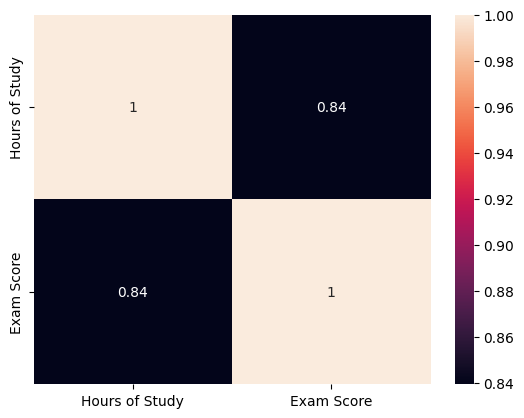

In [43]:
# correlation dekhar jonne ei seaborn library use kortesi
import seaborn as sns
# from matplotlib.typing import ColorType
sns.heatmap(dataset.corr(),annot=True)

## 🎨 Heatmap-কে আরও সুন্দর ও Unique করা

Heatmap-কে আরও প্রফেশনাল ও আকর্ষণীয় করার জন্য কিছু extra parameter যুক্ত করা হলো:

| Parameter | কাজ |
|---|---|
| `figsize` | প্লটের সাইজ বড় করে |
| `cmap` | রঙের থিম পরিবর্তন করে (যেমন `coolwarm`, `viridis`) |
| `annot=True` | সেলের ভেতরে সংখ্যা দেখায় |
| `fmt=".2f"` | সংখ্যাকে ২ দশমিক ঘর পর্যন্ত দেখায় |
| `linewidths`, `linecolor` | সেলের মাঝে বর্ডার লাইন যুক্ত করে |
| `cbar_kws` | পাশের Color Bar কাস্টমাইজ করে |
| `title()` | গ্রাফের শিরোনাম যুক্ত করে |

> 💡 **টিপস:** `cmap="coolwarm"` এ লাল রঙ Positive Correlation এবং নীল রঙ Negative Correlation বোঝায় — তাই সম্পর্ক বোঝা সহজ হয়।

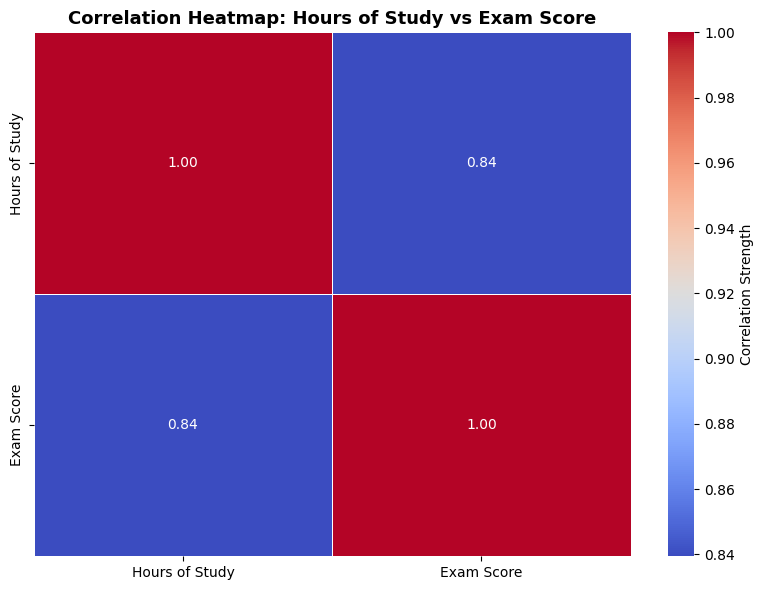

In [44]:
# প্লটের সাইজ বড় করা হচ্ছে
plt.figure(figsize=(8,6))

# Heatmap তৈরি করা হচ্ছে - cmap, fmt, linewidths যুক্ত করে আরও সুন্দর করা হলো
sns.heatmap(dataset.corr(),
            annot=True,           # সেলের ভেতরে সংখ্যা দেখাবে
            fmt=".2f",            # ২ দশমিক ঘর পর্যন্ত দেখাবে
            cmap="coolwarm",      # লাল = Positive, নীল = Negative correlation
            linewidths=0.5,       # সেলের মাঝে পাতলা বর্ডার
            linecolor="white",    # বর্ডারের রঙ
            cbar_kws={"label": "Correlation Strength"})  # সাইডবারের লেবেল

# গ্রাফের টাইটেল যুক্ত করা হচ্ছে
plt.title("Correlation Heatmap: Hours of Study vs Exam Score", fontsize=13, fontweight="bold")

# সব এলিমেন্ট সুন্দরভাবে ফিট করানো
plt.tight_layout()

# প্লট দেখানো
plt.show()

# 🎯 Independent ও Dependent Variable নির্ধারণ

## 🧠 থিওরি

Machine Learning Algorithm Apply করার আগে অবশ্যই ঠিক করতে হবে:

- **Independent Variable (X)**: যেটার উপর ভিত্তি করে Prediction করা হবে (Input/Feature)
- **Dependent Variable (Y)**: যেটা Predict করতে চাই (Output/Target)

**ML Agorithm apply korar age amake decide korte hobe who's dependent and who's indepedent** ✅

আমাদের ক্ষেত্রে:
- **X (Independent)** = "Hours of Study" → কারণ এটি দিয়ে আমরা Score অনুমান করব
- **Y (Dependent)** = "Exam Score" → কারণ এটি Study Hours-এর উপর নির্ভরশীল (depend করে)

### `train_test_split` কী?

`sklearn.model_selection` থেকে আসা এই ফাংশন Dataset কে দুই ভাগে ভাগ করে:
1. **Training Set** — মডেলকে শেখানোর জন্য
2. **Testing Set** — মডেল কতটা ভালো শিখেছে তা যাচাই করার জন্য

> ⚠️ **সাধারণ ভুল:** পুরো Dataset দিয়েই Train করে আবার সেই একই Data দিয়ে Test করলে মডেলের Performance ভুলভাবে ভালো দেখাবে (Overfitting বোঝা যাবে না)। তাই Train ও Test Data আলাদা হওয়া আবশ্যক।

In [45]:
from sklearn.model_selection import train_test_split

## 📥 X (Independent Variable) তৈরি করা

`dataset[["Hours of Study"]]` — এখানে **Double Bracket `[[ ]]`** ব্যবহার করা হয়েছে, কারণ:

- Single Bracket `[ ]` → একটি **Series** (1D) রিটার্ন করে
- Double Bracket `[[ ]]` → একটি **DataFrame** (2D) রিটার্ন করে

### কেন DataFrame (2D) প্রয়োজন?
**Scikit-learn** এর Model গুলো Input (X) হিসেবে সবসময় **2D Array/DataFrame** আশা করে — কারণ ভবিষ্যতে একাধিক Feature (Column) থাকতে পারে। যদি Single Bracket দিয়ে Series (1D) পাস করা হয়, তাহলে `ValueError` আসতে পারে।

> ⚠️ **সাধারণ ভুল:** নতুনরা প্রায়ই `dataset["Hours of Study"]` (Single Bracket) লিখে ফেলে, যার ফলে Model Training-এর সময় Shape Error দেখা যায়।

In [46]:
x=dataset[["Hours of Study"]]
x

,Hours of Study
0,1.2
1,1.7
2,4.0
3,6.0
4,5.5
5,6.3
6,6.6
7,3.2
8,6.5
9,4.5


## 📤 Y (Dependent/Target Variable) তৈরি করা

`dataset["Exam Score"]` — এখানে **Single Bracket** ব্যবহার করা হয়েছে, কারণ Target Variable (Y) সাধারণত একটি **Series (1D)** হিসেবেই দিতে হয় — Scikit-learn এর `fit()` ফাংশন Y এর জন্য 1D Array/Series আশা করে।

| Variable | Bracket | Type | কারণ |
|---|---|---|---|
| X (Feature) | `[[ ]]` | DataFrame (2D) | Model একাধিক feature নিতে পারে |
| Y (Target) | `[ ]` | Series (1D) | একটি single output column |

In [47]:
y=dataset["Exam Score"]
y

,Exam Score
0,300
1,470
2,500
3,600
4,500
5,700
6,850
7,480
8,810
9,490


# ✂️ Train-Test Split

## 🧠 থিওরি

`train_test_split()` ফাংশন X এবং Y কে একসাথে ৪ ভাগে ভাগ করে:

| ভ্যারিয়েবল | অর্থ |
|---|---|
| `xtrain` | Training এর জন্য Input Data |
| `xtest` | Testing এর জন্য Input Data |
| `ytrain` | Training এর জন্য Output/Target Data |
| `ytest` | Testing এর জন্য Output/Target Data (Actual Answer) |

### Parameters ব্যাখ্যা:

- **`test_size=0.2`** → মোট Dataset এর **20%** Testing-এর জন্য রাখা হবে, বাকি **80%** Training-এর জন্য
- **`random_state=0`** → এটি একটি **Seed Value**। এটি না দিলে প্রতিবার রান করলে আলাদা আলাদা Data Train/Test এ ভাগ হবে, ফলে Result পরিবর্তন হতে থাকবে। `random_state=0` দিলে সবসময় **একই বিভাজন (Split)** হবে — Reproducibility বজায় থাকে।

$$\text{Training Size} = (1 - \text{test\_size}) \times \text{Total Data}$$
$$\text{Testing Size} = \text{test\_size} \times \text{Total Data}$$

> ⚠️ **সাধারণ ভুল:**
> - `test_size` অনেক বেশি (যেমন 0.5) দিলে Training Data কমে যায়, মডেল ঠিকভাবে শিখতে পারে না
> - `random_state` না দিলে Result বারবার পরিবর্তন হবে, যা Debugging কঠিন করে তোলে
> - X এবং Y এর Order ভুল দিলে (যেমন `train_test_split(y,x,...)`) ভেরিয়েবলগুলোতে ভুল ডেটা চলে যাবে

In [48]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=0)

# 🤖 Linear Regression মডেল তৈরি করা

## 🧠 থিওরি

`sklearn.linear_model` থেকে `LinearRegression` Class import করে একটি **Object (lr)** তৈরি করা হচ্ছে। এই অবস্থায় মডেল এখনো কিছু শেখেনি — এটি শুধু একটি **খালি (Untrained) Model Structure**।

### Linear Regression কীভাবে কাজ করে?

মডেল একটি Best Fit Line খুঁজে বের করার চেষ্টা করে:

$$\hat{y} = m \cdot x + c$$

মডেল এমনভাবে $m$ (slope) এবং $c$ (intercept) এর মান বের করে যাতে **Actual Value এবং Predicted Value এর মধ্যে পার্থক্য (Error) সবচেয়ে কম হয়**। এই Error মাপার Formula কে বলা হয় **Cost Function (Mean Squared Error)**:

$$MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

In [49]:
from sklearn.linear_model import LinearRegression
lr= LinearRegression()

# 🏋️ মডেল ট্রেইন করা — `fit()`

## 🧠 থিওরি

**`fit(xtrain, ytrain)`** — এটিই হলো **Training (শেখানোর)** ধাপ।

**Ekhon Prothom kaj train kora** ✅

`fit()` ফাংশনে দুইটি জিনিস দেওয়া হয়:
- `xtrain` → প্রশ্ন (Question/Input)
- `ytrain` → উত্তর (Answer/Output)

মডেল এই Question-Answer Pair গুলো দেখে নিজে থেকে $m$ এবং $c$ এর মান শিখে নেয় (Internally Gradient Descent বা Normal Equation এর মাধ্যমে calculation হয়)।

### 📊 DataFrame vs Series — পার্থক্য

| | Dimension | উদাহরণ |
|---|---|---|
| **DataFrame** | 2D (Multi-dimensional, row+column) | `xtrain` |
| **Series** | 1D | `ytrain` |

> ⚠️ **সাধারণ ভুল:**
> - `fit(ytrain, xtrain)` — উল্টো ক্রমে দিলে মডেল সম্পূর্ণ ভুল শিখবে
> - `fit()` কল না করে সরাসরি `predict()` কল করলে `NotFittedError` আসবে

In [50]:
# Ekhon Prothom kaj train kora
lr.fit(xtrain,ytrain)
# xtrain,yrain nsi karon ekta hocche proshno, arekta hocche uttor. mane oke amra sikhaitesi
# dataframe on dimensional
# series hocche multidimensional

LinearRegression()

# 🔮 Prediction করা — `predict()`

## 🧠 থিওরি

মডেল Training শেষ হওয়ার পর, `predict(xtest)` ফাংশন দিয়ে **Test Data (যা মডেল আগে কখনো দেখেনি)** এর জন্য Output Predict করা হয়।

মডেল তার শেখা $m$ এবং $c$ মান দিয়ে নিচের সূত্র Apply করে প্রতিটি `xtest` value এর জন্য একটি `Exam Score` Predict করবে:

$$\hat{y}_{pred} = m \cdot x_{test} + c$$

> ⚠️ **সাধারণ ভুল:**
> - `predict(xtrain)` দিয়ে ভুলবশত Training Data দিয়ে Predict করা — এতে Model এর Real Performance বোঝা যায় না (যেহেতু মডেল এই Data আগেই দেখেছে)
> - `predict()` এর Input অবশ্যই `fit()` এর X এর মতো same shape (2D) হতে হবে

In [51]:
lr.predict(xtest)

array([507.23946266, 584.98785867, 493.10339066, 606.19196667,
       443.62713866, 542.57964267])

# ✅ Actual Value এর সাথে তুলনা — `ytest`

## 🧠 থিওরি

`ytest` হলো **Actual (সঠিক) Exam Score**, যা আমরা পূর্বেই Train-Test Split করার সময় আলাদা করে রেখেছিলাম।

এখন আমরা `lr.predict(xtest)` থেকে পাওয়া **Predicted Score** এবং `ytest` এর **Actual Score** পাশাপাশি দেখে বুঝতে পারব মডেল কতটা ভালো Prediction করছে।

### কীভাবে Model এর Performance যাচাই করা হয়?

| Metric | সূত্র | অর্থ |
|---|---|---|
| **MAE** | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | গড় Absolute Error |
| **MSE** | $\frac{1}{n}\sum(y_i - \hat{y}_i)^2$ | গড় বর্গাকার Error |
| **RMSE** | $\sqrt{MSE}$ | MSE এর Square Root |
| **R² Score** | $1 - \frac{SS_{res}}{SS_{tot}}$ | মডেল কতটা ভালো fit করেছে (0 থেকে 1) |

> 💡 **পরের ধাপ (Next Steps):** এখানে শুধু `ytest` প্রিন্ট করা হয়েছে — পরবর্তীতে `predict()` এর Output এবং `ytest` কে পাশাপাশি একটি DataFrame এ রেখে এবং উপরের Metrics গুলো (`from sklearn.metrics import ...`) ব্যবহার করে Model Accuracy যাচাই করা যেতে পারে।



In [52]:
ytest

,Exam Score
2,500
28,520
13,400
10,570
26,470
24,510


## 📊 Predicted vs Actual — পাশাপাশি তুলনা (DataFrame)

`lr.predict(xtest)` থেকে পাওয়া **Predicted Score** এবং `ytest` এর **Actual Score** কে একটি DataFrame এ পাশাপাশি রাখা হচ্ছে — এতে সহজেই বোঝা যাবে মডেল কোথায় ঠিকঠাক Predict করেছে আর কোথায় কতটুকু ভুল হয়েছে।

In [54]:
# Predicted এবং Actual Score পাশাপাশি DataFrame এ রাখা হচ্ছে
comparison = pd.DataFrame({
    "Actual Score": ytest.values,
    "Predicted Score": lr.predict(xtest).round(2)
})
comparison

,Actual Score,Predicted Score
0,500,507.24
1,520,584.99
2,400,493.10
3,570,606.19
4,470,443.63
5,510,542.58


## 📏 Model Accuracy যাচাই — Metrics

মডেল কতটা ভালো কাজ করছে তা পরিমাপ করার জন্য নিচের ৪টি Metric ব্যবহার করা হয়:

| Metric | সূত্র | অর্থ |
|---|---|---|
| **MAE** | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | গড় Error (Outlier-এ কম Sensitive) |
| **MSE** | $\frac{1}{n}\sum(y_i - \hat{y}_i)^2$ | বড় Error কে বেশি Penalize করে |
| **RMSE** | $\sqrt{MSE}$ | MSE এর Square Root — বোঝা সহজ |
| **R² Score** | $1 - \frac{SS_{res}}{SS_{tot}}$ | ১ এর কাছাকাছি হলে মডেল ভালো |

> 💡 **R² Score** সবচেয়ে গুরুত্বপূর্ণ — এটি বলে মডেল মোট Variance এর কতটুকু Explain করতে পারছে। R²=0.95 মানে ৯৫% Variance মডেল ধরতে পেরেছে।

In [58]:
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
import numpy as np

mae= mean_absolute_error(ytest,lr.predict(xtest))
mse= mean_squared_error(ytest, lr.predict(xtest))
rmse= np.sqrt(mse)
r2= r2_score(ytest, lr.predict(xtest))


print(f"MAE       :{mae:.4f}")
print(f"MSE       :{mse:.4f}")
print(f"RMSE      :{rmse:.4f}")
print(f"R-Square  :{r2:.4f}")

MAE       :43.4125
MSE       :2668.4821
RMSE      :51.6574
R-Square  :0.0086


## 📋 Metric এর ফলাফল বিশ্লেষণ — কোনটার মান কেমন হওয়া ভালো?

আমাদের মডেলের ফলাফল:

| Metric | আমাদের মান | ভালো হয় কখন | আমাদের ফলাফল |
|---|---|---|---|
| **MAE** | 43.41 | **কম হলে ভালো** ↓ | ❌ অনেক বেশি |
| **MSE** | 2668.48 | **কম হলে ভালো** ↓ | ❌ অনেক বেশি |
| **RMSE** | 51.65 | **কম হলে ভালো** ↓ | ❌ অনেক বেশি |
| **R² Score** | 0.0086 | **বেশি হলে ভালো, ১ এর কাছাকাছি** ↑ | ❌ অনেক কম |

### 🔍 সহজ ভাষায় বিশ্লেষণ:

- **MAE = 43.41** → মডেল গড়ে প্রতিটি Prediction এ **43 নাম্বার ভুল** করছে — এটা অনেক বেশি ভুল
- **MSE = 2668.48** → বড় Error গুলোকে Square করে যোগ করায় এই মান অনেক বেশি — মডেল বড় বড় ভুল করছে
- **RMSE = 51.65** → গড়ে প্রতিটি Prediction **প্রায় 51-52 নাম্বার** ব্যবধানে ভুল হচ্ছে
- **R² = 0.0086** → মানে মডেল মাত্র **0.86% Variance** Explain করতে পারছে — প্রায় **0 এর কাছাকাছি**, যার মানে মডেল কার্যত কিছুই শিখতে পারেনি

### 🧠 এত খারাপ ফলাফলের কারণ কী?

> "Hours of Study" এবং "Exam Score" এর মধ্যে **Correlation খুবই দুর্বল** — Heatmap এ যদি এই দুটির Correlation Value ০ বা ০ এর কাছাকাছি দেখায়, তাহলে Linear Regression কখনোই ভালো কাজ করবে না। Linear Regression ভালো কাজ করে যখন দুটি Variable এর মধ্যে **Strong Linear Relationship (Correlation ০.৭ বা তার বেশি)** থাকে।

## 📉 Best Fit Line Visualization

এখন **Scatter Plot** এর উপর **Best Fit Line** আঁকা হবে। এতে বোঝা যাবে মডেলের তৈরি সরলরেখা আসল Data Points এর কতটা কাছাকাছি।

- **নীল বিন্দু (Scatter)** → Actual Data Points
- **লাল রেখা (Line)** → মডেলের শেখা Best Fit Line: $\hat{y} = mx + c$

> 💡 রেখাটি যত বেশি Data Point এর মাঝখান দিয়ে যাবে, মডেল তত ভালো।

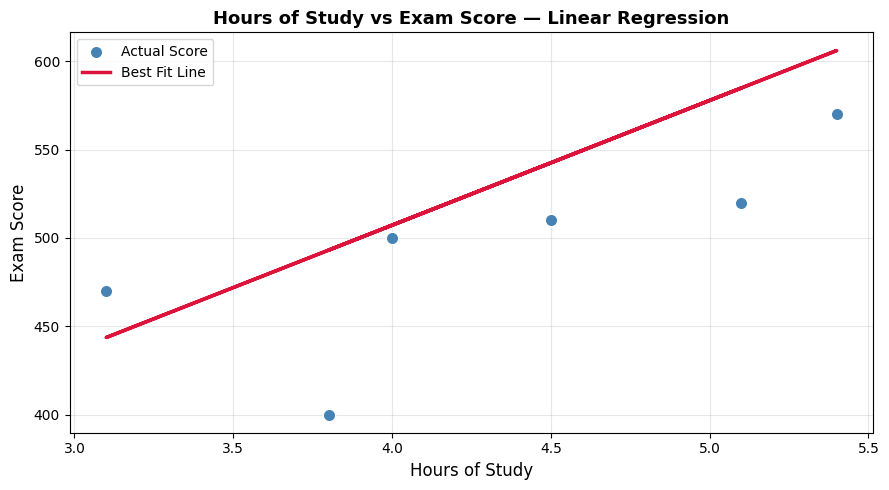

In [64]:
plt.figure(figsize=(9,5))

# Actual Data Points — Scatter Plot
plt.scatter(xtest, ytest, color="steelblue", label="Actual Score", edgecolors="white", s=80, zorder=3)

# Best Fit Line — Predicted Line
plt.plot(xtest, lr.predict(xtest), color="crimson", linewidth=2.5, label="Best Fit Line")

# Title ও Axis Label
plt.title("Hours of Study vs Exam Score — Linear Regression", fontsize=13, fontweight="bold")
plt.xlabel("Hours of Study", fontsize=12)
plt.ylabel("Exam Score", fontsize=12)

# Grid ও Legend
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 📊 Actual vs Predicted — Bar Chart তুলনা

প্রতিটি Test Sample এর জন্য **Actual** এবং **Predicted** Score পাশাপাশি Bar Chart এ দেখানো হচ্ছে — এতে কোন Sample এ মডেল কতটুকু ভুল করেছে তা স্পষ্টভাবে বোঝা যাবে।

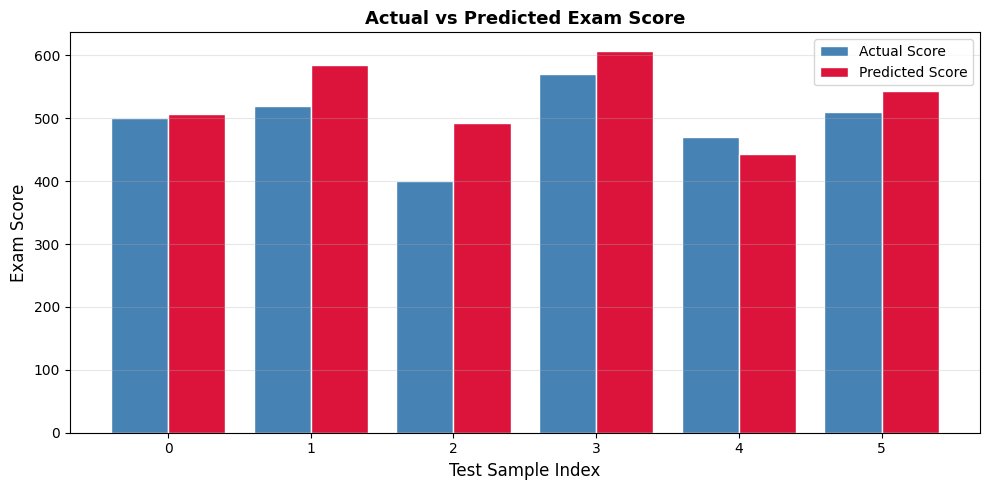

In [68]:
import numpy as np

x_axis = np.arange(len(ytest))

plt.figure(figsize=(10,5))

# Actual Score Bar
plt.bar(x_axis - 0.2, ytest.values, width=0.4, label="Actual Score", color="steelblue", edgecolor="white")

# Predicted Score Bar
plt.bar(x_axis + 0.2, lr.predict(xtest).round(2), width=0.4, label="Predicted Score", color="crimson", edgecolor="white")

plt.title("Actual vs Predicted Exam Score", fontsize=13, fontweight="bold")
plt.xlabel("Test Sample Index", fontsize=12)
plt.ylabel("Exam Score", fontsize=12)
plt.legend(fontsize=10)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

⭐ যদি এই নোটবুকটি ভালো লাগে, GitHub-এ Star দিতে ভুলো না!